# Random Forest

In [1]:
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd
from sklearn import datasets
from sklearn import linear_model

from sklearn.model_selection import train_test_split

from sklearn.metrics import r2_score, mean_squared_error

In [3]:

# Splitting the dataset into the Training set and Test set

X = np.load('../pollenGeolocation_saved/X.npy')
y = np.load('../pollenGeolocation_saved/y.npy')
#from sklearn.cross_validation import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 1, shuffle=True)
    
# Scaling
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test  = sc_X.transform(X_test)

# Random forest
from sklearn.ensemble import RandomForestRegressor
#rf =RandomForestRegressor(max_depth=2, n_estimators = 100, random_state=0) ###original
rf =RandomForestRegressor(n_estimators = 400, min_samples_split = 2, min_samples_leaf = 1, max_features = 'sqrt', max_depth = None, bootstrap = False) ###tuned
rf = rf.fit(X_train,y_train)
pred_train = rf.predict(X_train)
pred_test = rf.predict(X_test)

train_error = np.round(rf.score(X_train, y_train), 2)
test_error = np.round(rf.score(X_test, y_test), 2)    
print("Training Set Mean Accuracy = " + str(train_error))
print("Test Set Mean Accuracy = " + str(test_error))

print("R2 = " + " " + str(r2_score(y_test,pred_test)))
print("mse = " + " " + str(mean_squared_error(y_test,pred_test)))

y_test = np.hsplit(y_test, 2)
pred_test = np.hsplit(pred_test, 2)


Training Set Mean Accuracy = 1.0
Test Set Mean Accuracy = 0.98
R2 =  0.9814863686309301
mse =  0.18353203876235097


Most Important Features


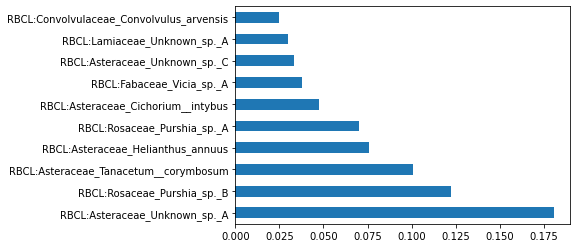

In [4]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score as acc
names = np.load('X_cols.npy', allow_pickle = True)
#reg= ExtraTreesRegressor()
rf.fit(X_train,y_train)
importance = rf.feature_importances_
#print(np.column_stack((names, importance)))
feat_importances = pd.Series(rf.feature_importances_, index=names)
print('Most Important Features')
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

In [5]:
y_test_new = np.column_stack((y_test[0],y_test[1])) 
preds_new = np.column_stack((pred_test[0],pred_test[1])) 
y_and_preds = np.concatenate((y_test_new,preds_new),axis=1)

import folium
from math import atan 
from folium.plugins import MarkerCluster

from geopy.distance import geodesic
def get_dists(real_predicted_coords):
    dists_list = []
    for line in real_predicted_coords:
        x = geodesic([line[0],line[1]], [line[2],line[3]]).mi
        dists_list.append(x)
    return dists_list
    
dists = get_dists(y_and_preds)

mapit = folium.Map( location=[36.1699, -115.1398], zoom_start=6)
folium.TileLayer('Stamen Terrain').add_to(mapit)
    
for coord in y_test_new:
    folium.Marker( location=[ coord[0], coord[1] ], icon=folium.Icon(color="green",icon="leaf", prefix='fa'), radius=8 ).add_to( mapit )    
marker_cluster = MarkerCluster().add_to(mapit)
for coord in y_test_new:
    folium.Marker(location=[ coord[0], coord[1] ], icon=folium.Icon(color="green",icon="leaf", prefix='fa'), radius=8).add_to(marker_cluster)
    
for coord in preds_new:
    folium.Marker( location=[ coord[0], coord[1] ], icon=folium.Icon(color="gray",icon="question-circle-o", prefix='fa'), radius=8 ).add_to( mapit )
    marker_cluster1 = MarkerCluster().add_to(mapit)
for coord in preds_new:
    folium.Marker(location=[ coord[0], coord[1] ], icon=folium.Icon(color="gray",icon="question-circle-o", prefix='fa')).add_to(marker_cluster1)


def assign_colors(dist_list):
    color_pick = []
    for lens in dists:
        if lens <= 5:
            color_pick.append('Green')
        elif 5 < lens <= 15:
            color_pick.append('Orange')
        elif lens > 15:
            color_pick.append('Red')
    return color_pick

my_colors = assign_colors(dists)    

marker_len = 0
for coord in y_and_preds:
    folium.PolyLine(locations = ([ coord[0], coord[1] ], [coord[2], coord[3]]), color=my_colors[marker_len]).add_to(mapit)
    marker_len += 1
    


This map shows actual data points with green leaf markers, while predictions are plotted with gray question markers. In places where several markers overlap, they are marked with a circle and overlayed with the number of points underneath it, and the points can be zoomed in and spread out by clicking the circle. The circles are colored by marker density, with green to yellow to orange signifying increasing number of points respectively. Line segments connect the actual points and the predicted points, with segment color corresponding to distance apart, with green = 5 miles or less, orange = 5-10 miles, and red = more than 10 miles. 

In [10]:
mapit

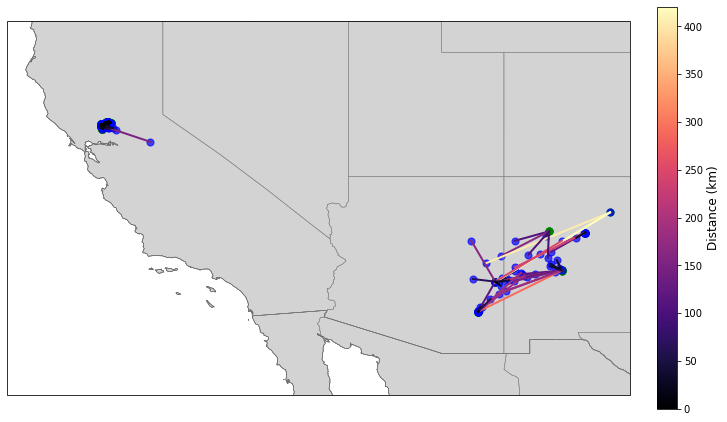

In [11]:
## updated solution
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from geopy.distance import geodesic

# Example `y_test` and `pred_test` arrays (replace these with your actual data)
y_test_new = np.column_stack((y_test[0], y_test[1]))  # True locations
preds_new = np.column_stack((pred_test[0], pred_test[1]))  # Predicted locations
y_and_preds = np.concatenate((y_test_new, preds_new), axis=1)

# Function to calculate distances
def get_dists(real_predicted_coords):
    return [
        geodesic([line[0], line[1]], [line[2], line[3]]).km
        for line in real_predicted_coords
    ]

# Calculate distances between true and predicted coordinates
dists = get_dists(y_and_preds)

# Normalize distances for the colormap
norm = mcolors.Normalize(vmin=min(dists), vmax=max(dists))
colormap = cm.magma

# Set up the map projection and figure
fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
# Adjust the map extent to focus on the southwestern U.S.
ax.set_extent([-125, -105, 30, 42])  # California, Arizona, New Mexico

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')

# Plot true locations
for coord in y_test_new:
    ax.scatter(coord[1], coord[0], color='green', s=50, label='True Location', alpha=0.7)

# Plot predicted locations
for coord in preds_new:
    ax.scatter(coord[1], coord[0], color='blue', s=50, label='Predicted Location', alpha=0.7)

# Add line segments with colors from the Magma colormap
for idx, coord in enumerate(y_and_preds):
    ax.plot(
        [coord[1], coord[3]],  # Longitudes
        [coord[0], coord[2]],  # Latitudes
        color=colormap(norm(dists[idx])),
        linewidth=2,
        transform=ccrs.PlateCarree()
    )

# Add a colorbar for the distances
sm = cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)
cbar.set_label('Distance (km)', fontsize=12)

# Save the static map for publication
plt.savefig('static_map_continuous_color.png', dpi=300, bbox_inches='tight')
plt.show()


2/9/2023 tutorial to make a model explainer: 

https://mljar.com/blog/feature-importance-in-random-forest/





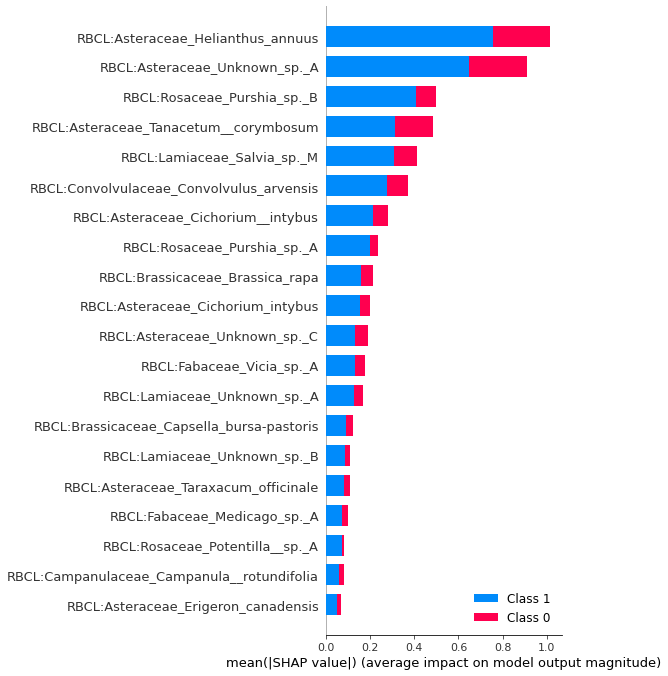

In [12]:
##SHAP
from sklearn.inspection import permutation_importance
import shap
from matplotlib import pyplot as plt

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=names, plot_type="bar")

In [14]:
## trying multioutput xgboost? 

